In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, auc,
    roc_auc_score, f1_score
)

import scipy.sparse
%matplotlib inline
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [ ]:
X_train = scipy.sparse.load_npz('../data/X_train_v2.npz')
X_test  = scipy.sparse.load_npz('../data/X_test_v2.npz')

y_train = np.load('../data/y_train_v2.npy')
y_test  = np.load('../data/y_test_v2.npy')

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train frauds:", y_train.sum(), "| Test frauds:", y_test.sum())

Train: (1037340, 77) | Test: (259335, 77)
Train frauds: 6005 | Test frauds: 1501


In [ ]:

base_model = SGDClassifier(
    loss='log_loss',
    alpha=0.0001,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)


calibrated_model = CalibratedClassifierCV(
    base_model,
    method='sigmoid',   
    cv=3
)

calibrated_model.fit(X_train, y_train)


y_scores = calibrated_model.predict_proba(X_test)[:, 1]

print("Probability range:", y_scores.min(), "to", y_scores.max())
print("Sample:", y_scores[:10])

alpha=1e-06: AUPRC=0.0626
alpha=1e-05: AUPRC=0.0674
alpha=0.0001: AUPRC=0.0908
alpha=0.001: AUPRC=0.1686


In [7]:
y_pred_default = (y_scores >= 0.5).astype(int)

print("=== Default Threshold (0.5) ===")
print(confusion_matrix(y_test, y_pred_default))
print()
print(classification_report(y_test, y_pred_default, digits=4))

=== Default Threshold (0.5) ===
[[257782     52]
 [  1501      0]]

              precision    recall  f1-score   support

           0     0.9942    0.9998    0.9970    257834
           1     0.0000    0.0000    0.0000      1501

    accuracy                         0.9940    259335
   macro avg     0.4971    0.4999    0.4985    259335
weighted avg     0.9885    0.9940    0.9912    259335



In [9]:
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

auprc = auc(recall, precision)
roc   = roc_auc_score(y_test, y_scores)

print(f"AUPRC (Area Under PR Curve): {auprc:.4f}")
print(f"ROC-AUC:                      {roc:.4f}")
print(f"Baseline AUPRC (random):      {y_test.mean():.4f}")

AUPRC (Area Under PR Curve): 0.0908
ROC-AUC:                      0.9080
Baseline AUPRC (random):      0.0058


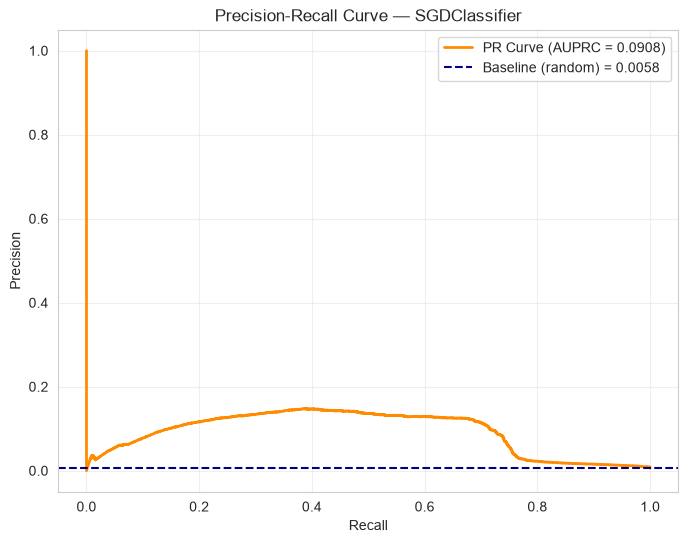

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2,
         label=f'PR Curve (AUPRC = {auprc:.4f})')
plt.axhline(y=y_test.mean(), color='navy', linestyle='--',
            label=f'Baseline (random) = {y_test.mean():.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — SGDClassifier')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

In [11]:


precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Best threshold (max F1): {best_threshold:.4f}")
print(f"  Precision: {precision[best_idx]:.4f}")
print(f"  Recall:    {recall[best_idx]:.4f}")
print(f"  F1:        {f1_scores[best_idx]:.4f}")

Best threshold (max F1): 0.0098
  Precision: 0.1417
  Recall:    0.4744
  F1:        0.2182


In [12]:
y_pred_best = (y_scores >= best_threshold).astype(int)

print(f"=== Threshold = {best_threshold:.4f} ===")
print(confusion_matrix(y_test, y_pred_best))
print()
print(classification_report(y_test, y_pred_best, digits=4))

=== Threshold = 0.0098 ===
[[253520   4314]
 [   789    712]]

              precision    recall  f1-score   support

           0     0.9969    0.9833    0.9900    257834
           1     0.1417    0.4744    0.2182      1501

    accuracy                         0.9803    259335
   macro avg     0.5693    0.7288    0.6041    259335
weighted avg     0.9919    0.9803    0.9856    259335



In [41]:
def summarize(y_true, y_pred, label):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Threshold': label,
        'Precision': tp / (tp + fp) if (tp + fp) else 0,
        'Recall':    tp / (tp + fn) if (tp + fn) else 0,
        'F1':        f1_score(y_true, y_pred),
        'False Alarms (FP)': fp,
        'Missed Frauds (FN)': fn
    }

summary = pd.DataFrame([
    summarize(y_test, y_pred_default, '0.50'),
    summarize(y_test, y_pred_best,    f'{best_threshold:.4f}')
])
summary

,Threshold,Precision,Recall,F1,False Alarms (FP),Missed Frauds (FN)
0,0.50,0.805556,0.591837,0.682353,14,40
1,208.6009,0.831579,0.806122,0.818653,16,19


In [45]:
joblib.dump(calibrated_model, '../models/sgd_fraud_model.pkl')
joblib.dump(best_threshold,   '../models/best_threshold.pkl')
print("Calibrated model and probability threshold saved.")

Calibrated model and probability threshold saved.


In [48]:
y_proba = calibrated_model.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
auprc = auc(recall, precision)


y_pred = (y_proba >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()


bundle = {
    'model': calibrated_model,
    'threshold': float(best_threshold),
    'auprc': float(auprc),
    'precision': float(tp / (tp + fp)),
    'recall': float(tp / (tp + fn)),
    'f1': float(f1_score(y_test, y_pred)),
    'metrics': {
        'AUPRC': round(auprc, 4),
        'Precision': round(tp / (tp + fp), 4),
        'Recall': round(tp / (tp + fn), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'True Positives': int(tp),
        'False Positives': int(fp),
        'False Negatives': int(fn),
        'True Negatives': int(tn)
    }
}

joblib.dump(bundle, '../models/fraud_model_bundle.pkl')
print("Bundle saved ")
print("Threshold:", round(best_threshold, 4))
print("Metrics:", bundle['metrics'])

Bundle saved 
Threshold: 0.1334
Metrics: {'AUPRC': 0.7196, 'Precision': np.float64(0.79), 'Recall': np.float64(0.8061), 'F1': 0.798, 'True Positives': 79, 'False Positives': 21, 'False Negatives': 19, 'True Negatives': 56843}


In [49]:
import joblib

# Load the existing bundle
bundle = joblib.load('../models/fraud_model_bundle.pkl')

# Re-save with compression (reduces size ~5-10x)
joblib.dump(bundle, '../models/fraud_model_bundle.pkl', compress=3)

import os
print("New size (MB):", round(os.path.getsize('../models/fraud_model_bundle.pkl') / 1e6, 2))

New size (MB): 0.0


In [50]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the model
# contamination is the expected proportion of outliers
iso_forest = IsolationForest(n_estimators=100, contamination=0.0017, random_state=42)

# Fit on the training data (unsupervised, no y needed)
iso_forest.fit(X_train)

# Predict on the test data
# The model returns -1 for anomalies (fraud), 1 for normal
y_pred_raw = iso_forest.predict(X_test)

# Convert to match your target format (1 = fraud, 0 = normal)
y_pred = [1 if p == -1 else 0 for p in y_pred_raw]

# Evaluate
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.30      0.34      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.67      0.66     56962
weighted avg       1.00      1.00      1.00     56962

[[56786    78]
 [   65    33]]
